In [ ]:
import re
import numpy as np
import pandas as pd
import random
import json
from collections import Counter
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from difflib import SequenceMatcher
import matplotlib.pyplot as plt
import os
from tensorboard.backend.event_processing import event_accumulator

model = SentenceTransformer("all-MiniLM-L6-v2")

In [56]:
def lexical_diversity_score(text):
    """
    Repetition score:
    1. Distinct-N: token diversity
    2. Consecutive duplicates: repeated words
    3. Burstiness: uneven token distribution
    4. Weighted: combine diversity and penalties
    """
    tokens = re.findall(r"\b\w+\b", text.lower())

    if len(tokens) < 4:
        return 1.0

    def distinct_n(tokens, n):
        if len(tokens) < n:
            return 1.0
        ngrams = [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]
        ratio = len(set(ngrams)) / len(ngrams)
        return np.sqrt(ratio) 

    d1 = distinct_n(tokens, 1)
    d2 = distinct_n(tokens, 2)
    d3 = distinct_n(tokens, 3)

    dup = sum(tokens[i] == tokens[i+1] for i in range(len(tokens)-1))
    dup_rate = dup / len(tokens)
    consecutive_penalty = np.power(1 - dup_rate, 0.5)

    counts = np.array(list({t: tokens.count(t) for t in set(tokens)}.values()))
    burstiness = np.std(counts) / (np.mean(counts) + 1e-6)
    
    score = (
        0.3 * d1 + 
        0.2 * d2 + 
        0.1 * d3 + 
        0.4 * consecutive_penalty
    ) - 0.05 * burstiness

    return float(np.clip(score, 0, 1))

def entity_score(text, expected_entities):
    """
    Entity score:
    1. Active recall: model mention vs prompt mention
    2. Balance: variance of entity mentions
    3. Hallucination: detect unexpected internal capitals
    """
    if not expected_entities:
        return 1.0

    text_lower = text.lower()
    expected_set = [e.lower() for e in expected_entities]
    counts = {e: len(re.findall(rf'\b{re.escape(e)}\b', text_lower)) for e in expected_set}
    c_values = list(counts.values())

    basic_recall = sum(1 for c in c_values if c > 0) / len(expected_set)
    active_recall = sum(1 for c in c_values if c >= 2) / len(expected_set)
    recall_score = (basic_recall * 0.3) + (active_recall * 0.7)

    found_counts = [c for c in c_values if c > 0]
    if len(found_counts) > 1:
        cv = np.std(found_counts) / (np.mean(found_counts) + 1e-6)
        balance_score = max(0, 1 - cv)
    else:
        balance_score = 1.0 if len(found_counts) == len(expected_set) else 0.0

    text_no_starts = re.sub(r'(?:^|[.!?]\s+|["\']\s*)[A-Z][a-z]+', ' ', text)
    internal_caps = set(re.findall(r'\b[A-Z][a-z]+\b', text_no_starts))
    internal_caps = {w for w in internal_caps if w not in {'I', 'A'}}
    actual_names = {w.lower() for w in internal_caps}
    hallucinated_names = actual_names - set(expected_set)
    hal_penalty = len(hallucinated_names) * 0.5

    final_score = (recall_score * 0.6) + (balance_score * 0.4) - hal_penalty
    return float(np.clip(final_score, 0, 1))

def structure_score(text, target_sentences=4):
    """
    Structure score:
    1. Sentence count: match target
    2. Boundaries: check punctuation
    3. Completion: check ending
    4. Length: very short or long penalty
    """
    tokens = text.split()
    length = len(tokens)

    sentence_count = len(re.findall(r"[.!?]", text))
    boundary_error = 1 if sentence_count == 0 else 0
    incomplete = 0 if text.strip().endswith(('.', '!', '?')) else 1
    structure_penalty = abs(sentence_count - target_sentences) / max(1, target_sentences)
    length_penalty = 1 if length < 15 or length > 200 else 0

    score = 1 - (0.3*incomplete + 0.3*structure_penalty + 0.2*boundary_error + 0.2*length_penalty)
    return max(0, min(1, score))

def coherence_score(text):
    """
    Coherence score:
    1. Sentence similarity: cosine between embeddings
    2. Connectors: check frequency of logical words
    3. Length variance: check sentence length consistency
    """
    sentences = re.split(r'[.!?]', text)
    sentences = [s.strip() for s in sentences if len(s.strip()) > 0]

    if len(sentences) < 2:
        return 1.0

    embeddings = model.encode(sentences)
    cos_vals = [cosine_similarity([embeddings[i]], [embeddings[i+1]])[0][0] for i in range(len(embeddings)-1)]
    mean_cos = np.mean(cos_vals)
    cos_error = 1 - mean_cos

    connectors = ["because", "then", "so", "after", "but"]
    conn_count = sum(text.lower().count(c) for c in connectors)
    conn_freq = conn_count / max(1, len(sentences))
    conn_error = 1 - min(conn_freq, 1)

    sentence_lengths = [len(s.split()) for s in sentences]
    var_len = np.var(sentence_lengths) / 100

    score = 1 - (0.4*cos_error + 0.3*var_len + 0.3*conn_error)
    return max(0, min(1, score))

def compute_all_scores(text, expected_entities, target_sentences=4):
    return {
        "lexical diversity": lexical_diversity_score(text),
        "entity": entity_score(text, expected_entities),
        "structure": structure_score(text, target_sentences),
        "coherence": coherence_score(text)
    }

In [ ]:
random.seed(42)

names = ["Alice", "Bob", "Tom", "Jack", "Emma", "Lucy",
         "Liam", "Noah", "Mia", "Olivia", "Ethan", "Ava"]
animals = ["dog", "cat", "rabbit", "fox", "bear", "bird"]
places = ["forest", "park", "school", "beach", "village"]
objects = ["ball", "map", "key", "book", "box", "treasure"]
causal_starters = [
    "because it was raining", "because he forgot his homework",
    "because the lights went out", "because she heard a strange noise"
]

eval_set = []

# 1️. Repetition
rep_templates = [
    "Once upon a time, there was a {animal} who",
    "In a small {place}, a {animal} discovered a {object} that",
    "Long ago, a {animal} wanted to",
    "One quiet night in the {place}, something strange",
    "A curious {animal} found a mysterious {object} and"
]

for _ in range(100):
    template = random.choice(rep_templates)
    prompt = template.format(
        animal=random.choice(animals),
        place=random.choice(places),
        object=random.choice(objects)
    )

    eval_set.append({
        "category": "repetition",
        "prompt": prompt,
        "expected_entities": []
    })


# 2️. Entity
entity_templates = [
    "{n1} and {n2} went to the {place} to find a {object}.",
    "{n1}, {n2}, and {n3} were playing in the {place}.",
    "At school, {n1} told {n2} about a {object}.",
    "{n1} helped {n2} after they lost a {object}."
]

for _ in range(100):
    template = random.choice(entity_templates)

    # randomly select 2 or 3 names
    num_names = random.choice([2, 3])
    sampled = random.sample(names, num_names)

    # ensure the length is 3
    while len(sampled) < 3:
        sampled.append(None)

    prompt = template.format(
        n1=sampled[0],
        n2=sampled[1],
        n3=sampled[2] if sampled[2] is not None else sampled[0],
        place=random.choice(places),
        object=random.choice(objects)
    )

    expected = [n for n in sampled if n is not None]

    eval_set.append({
        "category": "entity",
        "prompt": prompt,
        "expected_entities": expected
    })

# 3️. Structre 
structure_templates = [
    "Once upon a time, there was a {animal}.",
    "In a small {place}, a {animal} lived with his family.",
    "{n1} and {n2} were best friends.",
    "It was a cold day in the {place}."
]

for _ in range(100):
    template = random.choice(structure_templates)

    prompt = template.format(
        animal=random.choice(animals),
        place=random.choice(places),
        n1=random.choice(names),
        n2=random.choice(names)
    )

    eval_set.append({
        "category": "structure",
        "prompt": prompt,
        "expected_entities": []
    })


# 4️. Coherence
coherence_templates = [
    "{n1} was late for school {cause}, so",
    "A storm started in the {place}, and",
    "{n1} lost a {object}, then",
    "After {n1} found the {object},"
]

for _ in range(100):
    template = random.choice(coherence_templates)

    prompt = template.format(
        n1=random.choice(names),
        place=random.choice(places),
        object=random.choice(objects),
        cause=random.choice(causal_starters)
    )

    eval_set.append({
        "category": "coherence",
        "prompt": prompt,
        "expected_entities": []
    })

random.shuffle(eval_set)

with open("data/eval_set.json", "w") as f:
    json.dump(eval_set, f, indent=2)

print("Generated complex eval_set.json with", len(eval_set), "samples.")

In [ ]:
# Create the patch data
random.seed(42)

num_samples = 2000
names = [
    "Alice", "Bob", "Tom", "Jack", "Emma", "Lucy",
    "Liam", "Noah", "Mia", "Olivia", "Ethan", "Ava",
    "Sophia", "James", "Henry", "Grace", "Ella", "Leo",
    "Chloe", "Max"
]
places = [
    "forest", "park", "school", "beach", "village",
    "library", "museum", "playground", "zoo", "garden",
    "castle", "market", "river", "mountain", "cafe"
]
objects = [
    "ball", "map", "key", "book", "box", "treasure",
    "letter", "puzzle", "magic wand", "hat", "coin",
    "paintbrush", "kite", "lantern", "toy"
]

# Templates for 2 people
templates_2p = [
    "{p1} showed {p2} how to use it. Then, {p1} and {p2} went to the {place} together.",
    "{p2} was surprised when {p1} shared a {obj}. They laughed and played with it.",
    "{p1} and {p2} discovered a {obj} in the {place}. They decided to explore together.",
    "{p2} looked at {p1} as they found a {obj} at the {place}. Together, they had fun.",
    "In the {place}, {p1} handed a {obj} to {p2}. They played until sunset."
]

# Templetes for 3 people
templates_3p = [
    "{p1}, {p2}, and {p3} found a {obj} in the {place} and decided to share it. {p1} gave it to {p2}, then {p3} joined them.",
    "In the {place}, {p1}, {p2}, and {p3} discovered a {obj}. Together, they learned how to use it and had fun.",
    "{p1}, {p2}, and {p3} were curious about a {obj} in the {place}. After some adventures, they all became friends.",
    "At the {place}, {p3} noticed a {obj} and called {p1} and {p2} over. They played with it happily.",
    "While in the {place}, {p2} found a {obj}. {p1} and {p3} joined to explore and learn together."
]

entity_patch_data = []

for _ in range(num_samples):
    n_entities = random.choice([2, 3])
    sampled = random.sample(names, n_entities)
    
    random.shuffle(sampled)

    place = random.choice(places)
    obj = random.choice(objects)

    if n_entities == 2:
        p1, p2 = sampled
        prompt = f"At {place}, {p1} told {p2} about a {obj}."
        completion_template = random.choice(templates_2p)
        completion = completion_template.format(place=place, p1=p1, p2=p2, obj=obj)
    else:
        p1, p2, p3 = sampled
        prompt = f"{p1}, {p2}, and {p3} were playing in the {place}."
        completion_template = random.choice(templates_3p)
        completion = completion_template.format(place=place, p1=p1, p2=p2, p3=p3, obj=obj)

    entity_patch_data.append({
        "prompt": prompt,
        "completion": completion,
        "expected_entities": sampled
    })

with open("data/entity_patch.json", "w", encoding="utf-8") as f:
    json.dump(entity_patch_data, f, indent=2, ensure_ascii=False)

print(f"Generated Entity Patch with {len(entity_patch_data)} samples.")

In [ ]:
"""
These three are trained on Google Colab by utilizing T4 GPU
"""

# base model train
!python scripts/train_tinystories_model.py \
  --max_train_samples 200000 \
  --max_eval_samples 20000 \
  --batch_size 64 \
  --epochs 5 \
  --amp

# full fine-tuned model train
!python scripts/train_tinystories_model.py \
  --max_train_samples 200000 \
  --max_eval_samples 20000 \
  --batch_size 64 \
  --epochs 5 \
  --amp \
  --patch_file data/entity_patch.json


# LoRA fine-tuned model train
!python scripts/train_tinystories_LoRA_model.py \
  --max_train_samples 200000 \
  --max_eval_samples 20000 \
  --batch_size 64 \
  --epochs 5 \
  --lr 1e-4 \
  --amp \
  --patch_file data/entity_patch.json

'''
===> Loading pre-trained base model from tinystories_model/best_model.pth...
===> Base model loaded successfully!
trainable params: 32,768 || all params: 5,797,888 || trainable%: 0.5652

Epoch 1/5
Training epoch 1:   0% 0/3157 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Training epoch 1: 100% 3157/3157 [15:32<00:00,  3.38it/s, loss=1.4503]
Epoch 1/5, Average Train Loss: 1.4476, Train Perplexity: 4.25
Evaluating: 100% 313/313 [01:25<00:00,  3.66it/s]
Epoch 1/5, Validation Loss: 1.3815, Perplexity: 3.98
Model saved to tinystories_lora/model_epoch_1.pth
'''

In [ ]:
# Use base model to generate
! python scripts/generate_tinystories_text.py \
    --model_path results/models/tinystories_model/best_base_model.pth \
    --eval_path data/eval_set.json \
    --output_path outputs/base_outputs.json \
    --max_length 80

# Use full fine-tuned model to generate
! python scripts/generate_tinystories_text.py \
    --model_path results/models/tinystories_model/best_fullFT_model.pth \
    --eval_path data/eval_set.json \
    --output_path outputs/base_fullFT_outputs.json \
    --max_length 80

# # Use LoRA fine-tuned model to generate
! python scripts/generate_lora_tinystories.py \
    --model_path results/models/tinystories_model/best_lora_model.pth \
    --eval_path data/eval_set.json \
    --output_path outputs/base_lora_outputs.json \
    --max_length 80

In [85]:
def evaluate_file(path, model_name):
    with open(path, "r") as f:
        outputs = json.load(f)

    all_scores = []
    for item in outputs:
        text = item["generated"]
        expected_entities = item.get("expected_entities", [])
        scores = compute_all_scores(text, expected_entities)
        item["scores"] = scores
        all_scores.append(scores)

    avg_scores = {k: np.mean([s[k] for s in all_scores]) for k in all_scores[0]}
    avg_scores["model"] = model_name
    return avg_scores

base_row = evaluate_file("outputs/base_outputs.json", "base")
full_row = evaluate_file("outputs/base_fullFT_outputs.json", "full_finetune")
lora_row = evaluate_file("outputs/base_lora_outputs.json", "LoRA")

df = pd.DataFrame([base_row, full_row, lora_row]).set_index("model")
print(df)

               lexical diversity    entity  structure  coherence
model                                                           
base                    0.870643  0.890880   0.477313   0.529350
full_finetune           0.738211  0.972038   0.552938   0.639549
LoRA                    0.710378  0.951218   0.493500   0.603696


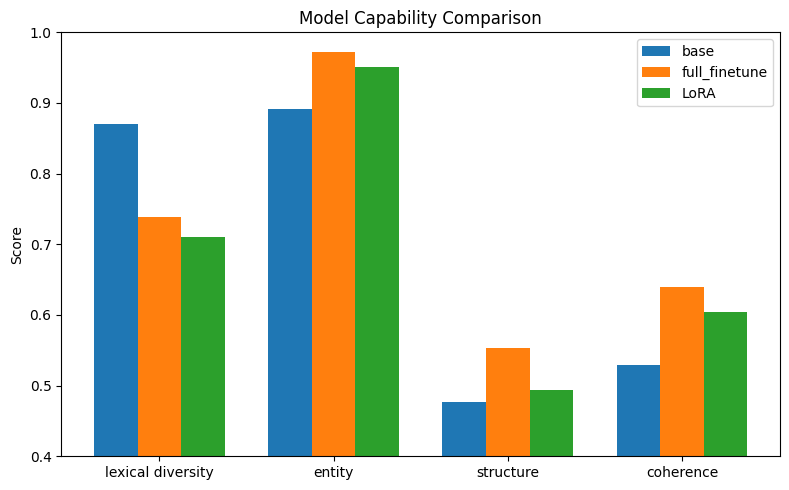

In [86]:
# Plot the metric comparison
x = np.arange(len(df.columns))
width = 0.25

fig, ax = plt.subplots(figsize=(8,5))

for i, model in enumerate(df.index):
    ax.bar(x + i*width, df.loc[model], width, label=model)

ax.set_xticks(x + width)
ax.set_xticklabels(df.columns)
ax.set_ylim(0.4, 1)
ax.set_ylabel("Score")
ax.set_title("Model Capability Comparison")
ax.legend()

plt.tight_layout()
# plt.savefig("results/plots/model_capability_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
def plot_training_results(log_dir):

    ea = event_accumulator.EventAccumulator(log_dir)
    ea.Reload()

    train_loss = pd.DataFrame(ea.Scalars('Loss/train'))
    val_loss = pd.DataFrame(ea.Scalars('Loss/val'))
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Left plot：Loss
    ax1.plot(train_loss['step'], train_loss['value'], label='Train Loss', color='blue', alpha=0.6)
    ax1.plot(val_loss['step'], val_loss['value'], label='Val Loss', color='red', linewidth=2)
    ax1.set_title('Cross-Entropy Loss')
    ax1.set_xlabel('Steps')
    ax1.legend()

    # Right plot：Perplexity
    train_ppl = pd.DataFrame(ea.Scalars('Perplexity/train'))
    val_ppl = pd.DataFrame(ea.Scalars('Perplexity/val'))
    
    ax2.plot(train_ppl['step'], train_ppl['value'], label='Train PPL', color='blue', alpha=0.6)
    ax2.plot(val_ppl['step'], val_ppl['value'], label='Val PPL', color='red', linewidth=2)
    ax2.set_title('Perplexity ($e^{Loss}$)')
    ax2.set_xlabel('Steps')
    ax2.legend()

    plt.tight_layout()
    plt.savefig(f"results/plots/{log_dir}_loss_perplexity.png", dpi=300, bbox_inches="tight")
    plt.show()

plot_training_results('tinystories_model')
plot_training_results('tinystories_lora')

In [ ]:
! python scripts/generate_tinystories_text.py \
    --model_path results/models/tinystories_model/best_base_model.pth \
    --prompt "Two curious cats Tom and Julia found a mysterious book and" \
    --max_length 100

In [ ]:
! python scripts/generate_tinystories_text.py \
    --model_path results/models/tinystories_model/best_fullFT_model.pth \
    --prompt "Two curious cats Tom and Julia found a mysterious book and" \
    --max_length 100

In [ ]:
! python scripts/generate_lora_tinystories.py \
    --model_path results/models/tinystories_model/best_lora_model.pth \
    --prompt "Two curious cats Tom and Julia found a mysterious book and" \
    --max_length 100